Primera parte de la tarea Diabetes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 1. Carga del dataset CSV
ARCHIVO = "/content/drive/MyDrive/Colab Notebooks/Fundamentos de Ciencia de Datos/Diabetes/diabetes.csv"
completo = pd.read_csv(ARCHIVO)

for df in (completo,):
    df.columns = [str(c).strip() for c in df.columns]
# Variables médicas donde un 0 representa un valor nulo/inválido
COLUMNAS_MEDICAS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


In [4]:
# 2. Separación en Completo, Depurado y Excluidas
depurado = completo.copy()
filtro_ceros = (depurado[COLUMNAS_MEDICAS] == 0).any(axis=1)

excluidas = depurado[filtro_ceros].copy()
depurado = depurado[~filtro_ceros].dropna().copy()
completo = completo.dropna().copy()

print(f"Registros totales: {len(completo):,}")
print(f"Registros depurados: {len(depurado):,}")
print(f"Registros excluidos: {len(excluidas):,}")

display(completo.head(10))

Registros totales: 768
Registros depurados: 768
Registros excluidos: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
5,5,116,74.0,27,102.5,25.6,0.201,30,0
6,3,78,50.0,32,88.0,31.0,0.248,26,1
7,10,115,70.0,27,102.5,35.3,0.134,29,0
8,2,197,70.0,45,543.0,30.5,0.158,53,1
9,8,125,96.0,32,169.5,34.3,0.232,54,1


In [5]:
# 3. Funciones de Gini y Entropía
def gini(valores):
    x = np.sort(np.asarray(valores, dtype=float))
    if len(x) == 0 or x.sum() == 0:
        return np.nan
    n = len(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) / (n * x.sum())) - (n + 1) / n

def entropia_normalizada(valores):
    p = np.asarray(valores, dtype=float)
    p = p[p > 0]
    if len(p) <= 1 or p.sum() == 0:
        return 0.0
    p = p / p.sum()
    h = -(p * np.log(p)).sum()
    return h / np.log2(len(p))

In [6]:
# 4. Función de resumen estadístico
def resumen_estadistico(df, nombre):
    if df.empty:
        return pd.Series({"Corpus": nombre})

    # Extraemos todos los valores de las columnas biométricas
    f = pd.Series(df[COLUMNAS_MEDICAS].values.flatten()).dropna()
    modos = f.mode().tolist()

    return pd.Series({
        "Corpus": nombre,
        "Suma total valores": int(f.sum()),
        "Total datos": int(f.size),
        "Media": f.mean(),
        "Mediana": f.median(),
        "Moda": ", ".join(map(str, modos[:3])),
        "Q1(25%)": f.quantile(.25),
        "Q2(50%)": f.quantile(.50),
        "Q3(75%)": f.quantile(.75),
        "Q90": f.quantile(.90),
        "Q95": f.quantile(.95),
        "Máximo": f.max(),
        "Rango": f.max() - f.min(),
        "Varianza muestral": f.var(ddof=1),
        "Desviación estándar muestral": f.std(ddof=1),
        "Asimetria": f.skew(),
        "Curtosis exceso": f.kurt(),
        "Diversidad de datos": f.nunique() / f.sum() if f.sum() != 0 else 0,
        "Entropía normalizada": entropia_normalizada(f),
        "Gini": gini(f),
    })



In [7]:
# 5. Generación e impresión de la tabla final
resumen = pd.DataFrame([
    resumen_estadistico(completo, "Completo"),
    resumen_estadistico(depurado, "Depurado"),
    resumen_estadistico(excluidas, "Excluidas")
]).set_index("Corpus").T

display(resumen)

Corpus,Completo,Depurado,Excluidas
Suma total valores,305160.0,305160.0,NaN
Total datos,3840.0,3840.0,NaN
Media,79.468958,79.468958,NaN
Mediana,70.0,70.0,NaN
Moda,102.5,102.5,NaN
Q1(25%),32.0,32.0,NaN
Q2(50%),70.0,70.0,NaN
Q3(75%),102.5,102.5,NaN
Q90,158.1,158.1,NaN
Q95,171.0,171.0,NaN


In [8]:
# Se puede responder. ¿Qué causa la diabetes por el momento?
'''
No. Este conjunto de datos no puede decirnos la causa directa de la diabetes.
¿Por qué?
Solo nos muestra factores que *están relacionados* con la diabetes (como la edad, el peso o la glucosa alta), pero no tiene la información necesaria para probar qué *provoca* la enfermedad.
'''

'\nNo. Este conjunto de datos no puede decirnos la causa directa de la diabetes.\n¿Por qué?\nSolo nos muestra factores que *están relacionados* con la diabetes (como la edad, el peso o la glucosa alta), pero no tiene la información necesaria para probar qué *provoca* la enfermedad.\n'

Segunda parte de la tarea diabetes

In [9]:
!pip install statsmodels

In [10]:
!pip install wquantiles

In [11]:
from scipy.stats import trim_mean #media truncada
from statsmodels import robust
import wquantiles
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
completo.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [13]:
completo.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76.0,48,180.0,32.9,0.171,63,0
764,2,122,70.0,27,102.5,36.8,0.340,27,0
765,5,121,72.0,23,112.0,26.2,0.245,30,0
766,1,126,60.0,32,169.5,30.1,0.349,47,1
767,1,93,70.0,31,102.5,30.4,0.315,23,0


In [14]:
completo.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
340,1,130,70.0,13,105.0,25.9,0.472,22,0
630,7,114,64.0,32,169.5,27.4,0.732,34,1
437,5,147,75.0,27,102.5,29.9,0.434,28,0
123,5,132,80.0,27,102.5,26.8,0.186,69,0
488,4,99,72.0,17,102.5,25.6,0.294,28,0
179,5,130,82.0,32,169.5,39.1,0.956,37,1
271,2,108,62.0,32,56.0,25.2,0.128,21,0
132,3,170,64.0,37,225.0,34.5,0.356,30,1
321,3,112,74.0,30,169.5,31.6,0.197,25,1
114,7,160,54.0,32,175.0,30.5,0.588,39,1


In [15]:
completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [16]:
completo.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [17]:
completo['Glucose'].mean()

np.float64(121.67708333333333)

In [19]:
trim_mean(completo['Glucose'], 0.1)

np.float64(119.66233766233766)

In [20]:
completo.Glucose.median()

117.0

In [22]:
# Media ponderada de la glucosa, dando más importancia a quienes tuvieron más embarazos.
np.average(completo.Glucose, weights=completo.Pregnancies)

np.float64(125.14730782255333)

In [23]:
wquantiles.median(completo.Glucose, weights=completo.Pregnancies)

np.float64(122.0)

<Axes: >

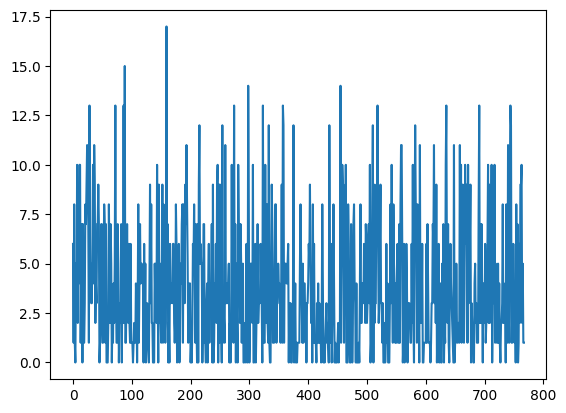

In [24]:
completo.Pregnancies.plot.line()

<Axes: >

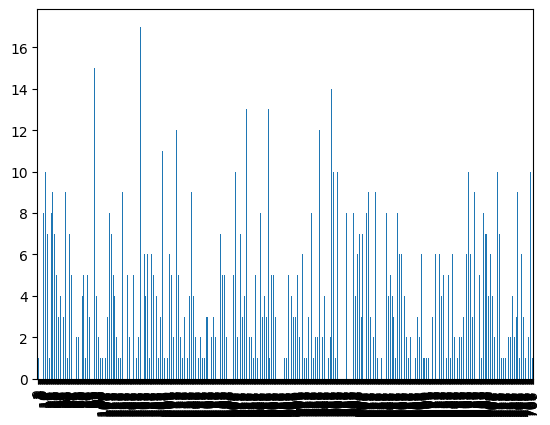

In [25]:
completo.Pregnancies.plot.bar()

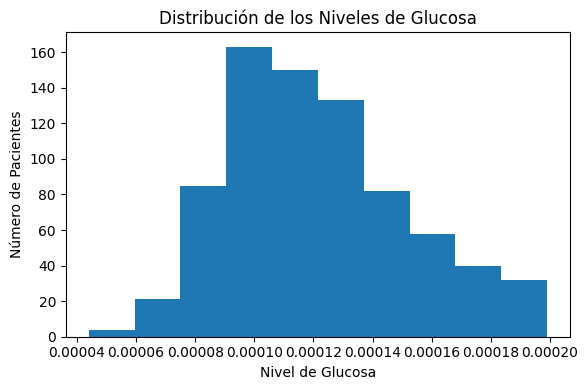

In [28]:
ax = (completo.Glucose/1_000_000).plot.hist(figsize=(6,4))
ax.set_xlabel("Nivel de Glucosa")
ax.set_ylabel("Número de Pacientes")
ax.set_title("Distribución de los Niveles de Glucosa")

plt.tight_layout()
plt.show()

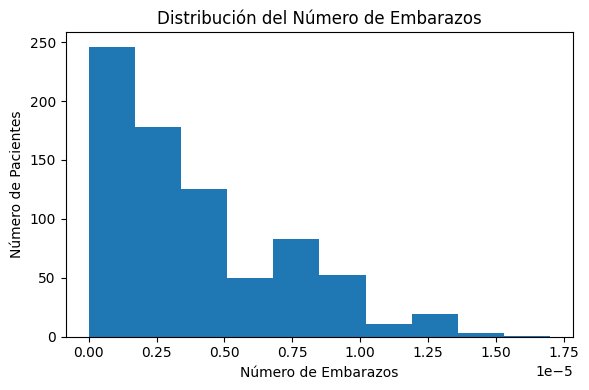

In [29]:
ax = (completo.Pregnancies/1_000_000).plot.hist(figsize=(6,4))
ax.set_xlabel("Número de Embarazos")
ax.set_ylabel("Número de Pacientes")
ax.set_title("Distribución del Número de Embarazos")

plt.tight_layout()
plt.show()

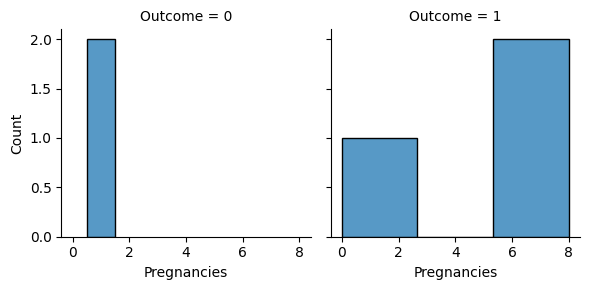

In [33]:
analisis = completo.head()
g = sns.FacetGrid(analisis,col="Outcome")
g.map(sns.histplot,"Pregnancies")

Estimación de la variabilidad

In [34]:
completo.Glucose.std()

30.46416058912223

In [35]:
completo.Pregnancies.std()

3.3695780626988623

In [36]:
completo["Glucose"].quantile(0.75) - completo["Glucose"].quantile(0.25)

np.float64(40.5)

In [37]:
completo["Pregnancies"].quantile(0.75) - completo["Pregnancies"].quantile(0.25)

np.float64(5.0)

Exploracion de distribucion de datos usando graficos

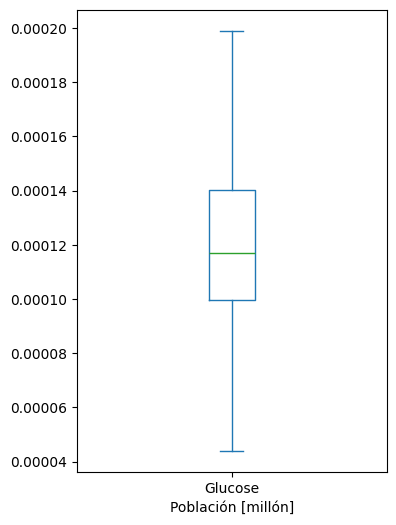

In [38]:
ax=(completo.Glucose/1_000_000).plot.box(figsize=(4,6))
ax.set_xlabel("Población [millón]")

plt.show()

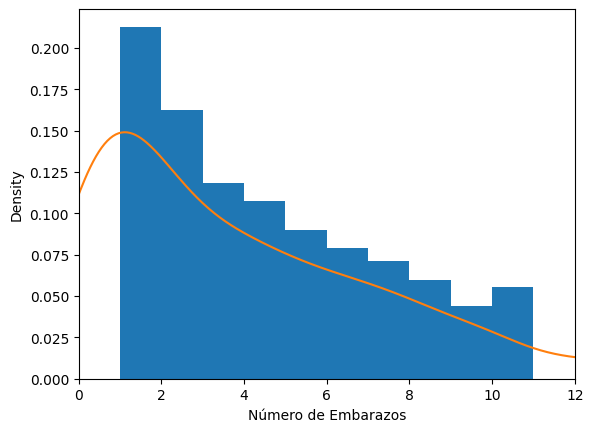

In [40]:
ax=(completo["Pregnancies"]).plot.hist(density=True, xlim=[0,12],bins=range(1,12))
completo["Pregnancies"].plot.density(ax=ax)
ax.set_xlabel("Número de Embarazos")

plt.show()

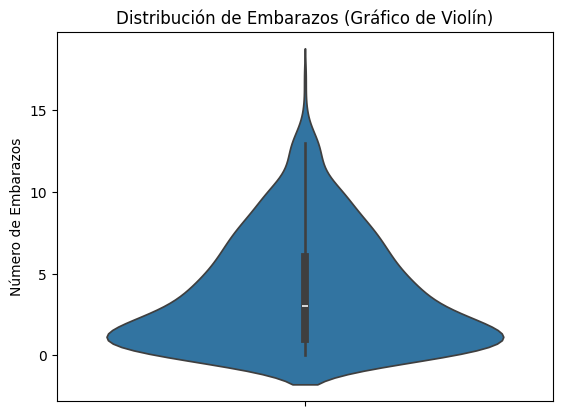

In [42]:
ax = sns.violinplot(y=completo["Pregnancies"])
ax.set_title("Distribución de Embarazos (Gráfico de Violín)")
ax.set_ylabel("Número de Embarazos")
plt.show()

In [43]:
mad_glucose = robust.mad(completo.Glucose)
mad_pregnancies = robust.mad(completo.Pregnancies)

print(f"Desviación Absoluta de la Mediana (MAD) - Glucosa: {mad_glucose:.2f} mg/dL")
print(f"Desviación Absoluta de la Mediana (MAD) - Embarazos: {mad_pregnancies:.2f}")

# Comparación con la Desviación Estándar para ver el efecto de los outliers
print(f"\nDesviación Estándar (Glucosa) para comparar: {completo.Glucose.std():.2f} mg/dL")

Desviación Absoluta de la Mediana (MAD) - Glucosa: 29.65 mg/dL
Desviación Absoluta de la Mediana (MAD) - Embarazos: 2.97

Desviación Estándar (Glucosa) para comparar: 30.46 mg/dL


In [ ]:
# Se puede responder. ¿Qué causa la diabetes por el momento?
'''
No, este conjunto de datos no puede determinar la causa directa de la diabetes.
Solo muestra factores que *están relacionados* con la diabetes (como la edad,
el peso o la glucosa alta), pero no contiene la información necesaria para
establecer las causas directas de la enfermedad.
'''